# 🎌 Anime Dataset Analysis using Data Analytics and AI

**IBM SkillsBuild Data Analytics with AI Academic Internship Project**

**Student:** Anaya

This project analyzes a publicly available MyAnimeList anime dataset using Python, exploratory data analysis, visualization, and K-Means clustering.

> **Important:** The dataset is loaded directly from a public CSV URL. You do **not** need to download or upload `anime.csv` manually.


## 1. Project Objectives

- Load a public anime dataset directly from the internet.
- Clean and validate the dataset.
- Analyze anime ratings and popularity.
- Analyze anime types and genres.
- Study the relationship between rating and community size.
- Apply K-Means clustering as the AI component.
- Evaluate clusters using silhouette score.
- Generate final analytical insights.


In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
# ==========================================
# 2. LOAD PUBLIC DATASET
# ==========================================

DATA_URL = "https://raw.githubusercontent.com/meesvandongen/anime-dataset/main/data/anime.csv"

print("Loading dataset from public URL...")
print(DATA_URL)

try:
    df = pd.read_csv(DATA_URL)
except Exception as e:
    raise RuntimeError(
        "The public dataset could not be loaded. "
        "Check your internet connection and try again."
    ) from e

print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Loading dataset from public URL...
https://raw.githubusercontent.com/meesvandongen/anime-dataset/main/data/anime.csv

Dataset loaded successfully!
Rows: 25576
Columns: 18


,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,4/19644,8.75,50.0,2087705,1076292,26,1998-04-03,1999-04-24,tv,finished_airing,r,1440,1;50;46;24;29,14
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,1439/93480,8.38,247.0,417053,234544,1,2001-09-01,2001-09-01,movie,finished_airing,r,6911,1;50;24;29,4
2,6,Trigun,トライガン,Trigun,1130/120002,8.22,430.0,845602,405534,26,1998-04-01,1998-09-30,tv,finished_airing,pg_13,1480,1;50;2;24;27,11
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,10/19969,7.24,3538.0,132042,46658,26,2002-07-03,2002-12-25,tv,finished_airing,pg_13,1500,1;39;8;7;37,14
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,7/21569,6.97,4990.0,16792,6979,52,2004-09-30,2005-09-29,tv,finished_airing,pg,1380,1;2;10;27,18


In [3]:
# ==========================================
# 3. INSPECT DATASET
# ==========================================

print("Original columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nDuplicate rows:", df.duplicated().sum())


Original columns:
['id', 'title', 'titleJa', 'titleEn', 'image', 'mean', 'rank', 'num_list_users', 'num_scoring_users', 'num_episodes', 'start_date', 'end_date', 'media_type', 'status', 'rating', 'average_episode_duration', 'genres', 'studios']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 25576 entries, 0 to 25575
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        25576 non-null  int64  
 1   title                     25576 non-null  str    
 2   titleJa                   25478 non-null  str    
 3   titleEn                   12423 non-null  str    
 4   image                     25472 non-null  str    
 5   mean                      19385 non-null  float64
 6   rank                      18483 non-null  float64
 7   num_list_users            25576 non-null  int64  
 8   num_scoring_users         25576 non-null  int64  
 9   num_episodes             

titleEn              13153
studios               8053
rank                  7093
mean                  6191
end_date               594
rating                 274
image                  104
titleJa                 98
genres                  76
id                       0
title                    0
num_episodes             0
num_list_users           0
num_scoring_users        0
status                   0
dtype: int64


Duplicate rows: 0


In [4]:
# ==========================================
# 4. STANDARDIZE COLUMN NAMES
# ==========================================

df.columns = [
    str(col).strip().lower().replace(" ", "_")
    for col in df.columns
]

print("Standardized columns:")
print(df.columns.tolist())


Standardized columns:
['id', 'title', 'titleja', 'titleen', 'image', 'mean', 'rank', 'num_list_users', 'num_scoring_users', 'num_episodes', 'start_date', 'end_date', 'media_type', 'status', 'rating', 'average_episode_duration', 'genres', 'studios']


In [5]:
# ==========================================
# 5. DATA CLEANING
# ==========================================

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Convert common numeric columns when available
numeric_candidates = [
    "score", "rating", "episodes", "members",
    "favorites", "popularity", "ranked",
    "watching", "completed", "on_hold",
    "dropped", "plan_to_watch"
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Replace impossible infinite values
df = df.replace([np.inf, -np.inf], np.nan)

print("Cleaned dataset shape:", df.shape)
display(df.head())


Cleaned dataset shape: (25576, 18)


,id,title,titleja,titleen,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,4/19644,8.75,50.0,2087705,1076292,26,1998-04-03,1999-04-24,tv,finished_airing,NaN,1440,1;50;46;24;29,14
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,1439/93480,8.38,247.0,417053,234544,1,2001-09-01,2001-09-01,movie,finished_airing,NaN,6911,1;50;24;29,4
2,6,Trigun,トライガン,Trigun,1130/120002,8.22,430.0,845602,405534,26,1998-04-01,1998-09-30,tv,finished_airing,NaN,1480,1;50;2;24;27,11
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,10/19969,7.24,3538.0,132042,46658,26,2002-07-03,2002-12-25,tv,finished_airing,NaN,1500,1;39;8;7;37,14
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,7/21569,6.97,4990.0,16792,6979,52,2004-09-30,2005-09-29,tv,finished_airing,NaN,1380,1;2;10;27,18


## 6. Dataset Summary


In [6]:
# ==========================================
# 6. DATASET SUMMARY
# ==========================================

summary = {
    "Total anime records": len(df)
}

rating_col = None
if "score" in df.columns:
    rating_col = "score"
elif "rating" in df.columns:
    rating_col = "rating"

if rating_col:
    valid_scores = df.loc[
        df[rating_col].notna() & (df[rating_col] > 0),
        rating_col
    ]
    summary["Records with valid rating"] = len(valid_scores)
    summary["Average rating"] = round(valid_scores.mean(), 2)

if "members" in df.columns:
    summary["Total community members"] = int(
        df["members"].fillna(0).sum()
    )

display(pd.DataFrame({
    "Metric": list(summary.keys()),
    "Value": list(summary.values())
}))


,Metric,Value
0,Total anime records,25576.0
1,Records with valid rating,0.0
2,Average rating,NaN


## 7. Rating Distribution


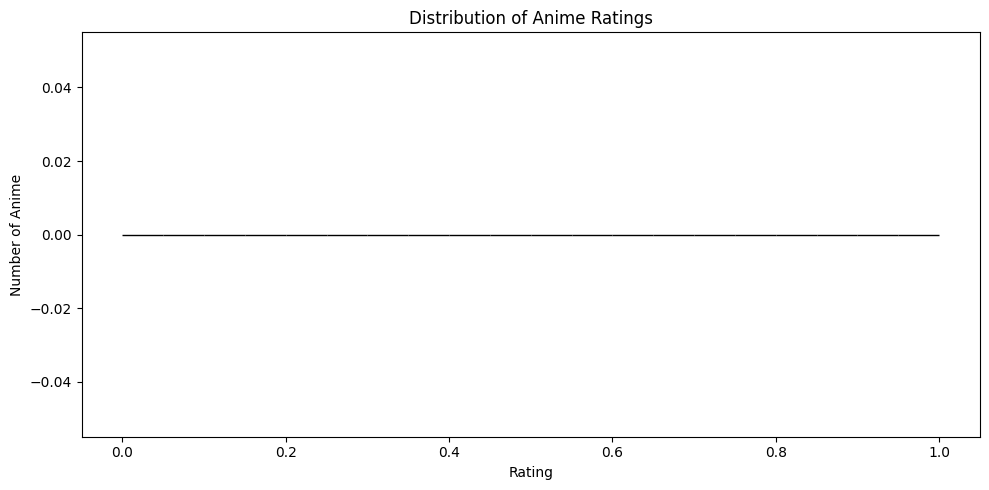

In [7]:
# ==========================================
# 7. RATING DISTRIBUTION
# ==========================================

if rating_col:
    rating_data = df.loc[
        df[rating_col].notna() & (df[rating_col] > 0),
        rating_col
    ]

    plt.figure(figsize=(10, 5))
    plt.hist(rating_data, bins=20, edgecolor="black")
    plt.title("Distribution of Anime Ratings")
    plt.xlabel("Rating")
    plt.ylabel("Number of Anime")
    plt.tight_layout()
    plt.show()
else:
    print("No rating/score column is available.")


## 8. Top Rated Anime


,title,rating


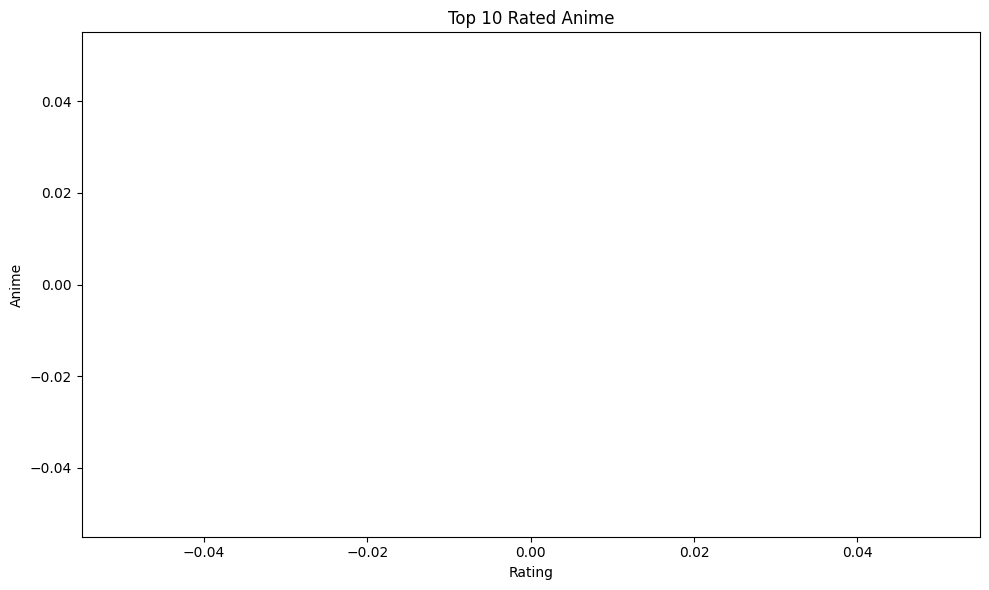

In [8]:
# ==========================================
# 8. TOP RATED ANIME
# ==========================================

if rating_col:
    rated = df[
        df[rating_col].notna() & (df[rating_col] > 0)
    ].copy()

    # Require a reasonable community size where available
    if "members" in rated.columns:
        rated = rated[rated["members"].fillna(0) >= 1000]

    rated = rated.sort_values(
        rating_col,
        ascending=False
    ).head(10)

    name_col = "name"
    if name_col not in rated.columns:
        name_col = "title" if "title" in rated.columns else rated.columns[0]

    display_cols = [name_col, rating_col]

    if "members" in rated.columns:
        display_cols.append("members")

    display(rated[display_cols])

    plt.figure(figsize=(10, 6))
    plt.barh(
        rated[name_col].astype(str).iloc[::-1],
        rated[rating_col].iloc[::-1]
    )
    plt.title("Top 10 Rated Anime")
    plt.xlabel("Rating")
    plt.ylabel("Anime")
    plt.tight_layout()
    plt.show()


## 9. Most Popular Anime


In [9]:
# ==========================================
# 9. MOST POPULAR ANIME
# ==========================================

if "members" in df.columns:

    name_col = "name"
    if name_col not in df.columns:
        name_col = "title" if "title" in df.columns else df.columns[0]

    popular = (
        df.dropna(subset=["members"])
        .sort_values("members", ascending=False)
        .head(10)
    )

    display(popular[[name_col, "members"]])

    plt.figure(figsize=(10, 6))
    plt.barh(
        popular[name_col].astype(str).iloc[::-1],
        popular["members"].iloc[::-1]
    )
    plt.title("Top 10 Anime by Community Members")
    plt.xlabel("Members")
    plt.ylabel("Anime")
    plt.tight_layout()
    plt.show()

else:
    print("The dataset does not contain a members column.")


The dataset does not contain a members column.


## 10. Anime Type Analysis


In [10]:
# ==========================================
# 10. ANIME TYPE ANALYSIS
# ==========================================

if "type" in df.columns:

    type_counts = (
        df["type"]
        .fillna("Unknown")
        .value_counts()
        .head(10)
    )

    display(type_counts.rename("Count").to_frame())

    plt.figure(figsize=(9, 5))
    plt.bar(type_counts.index.astype(str), type_counts.values)
    plt.title("Anime Count by Type")
    plt.xlabel("Type")
    plt.ylabel("Number of Anime")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

else:
    print("The dataset does not contain a type column.")


The dataset does not contain a type column.


## 11. Genre Analysis


Top 15 Anime Genres:


,Count
genres,
19,2077
12,1239
15;19,935
4,896
15,396
5;19,280
36,262
10;15,262
4;15,243


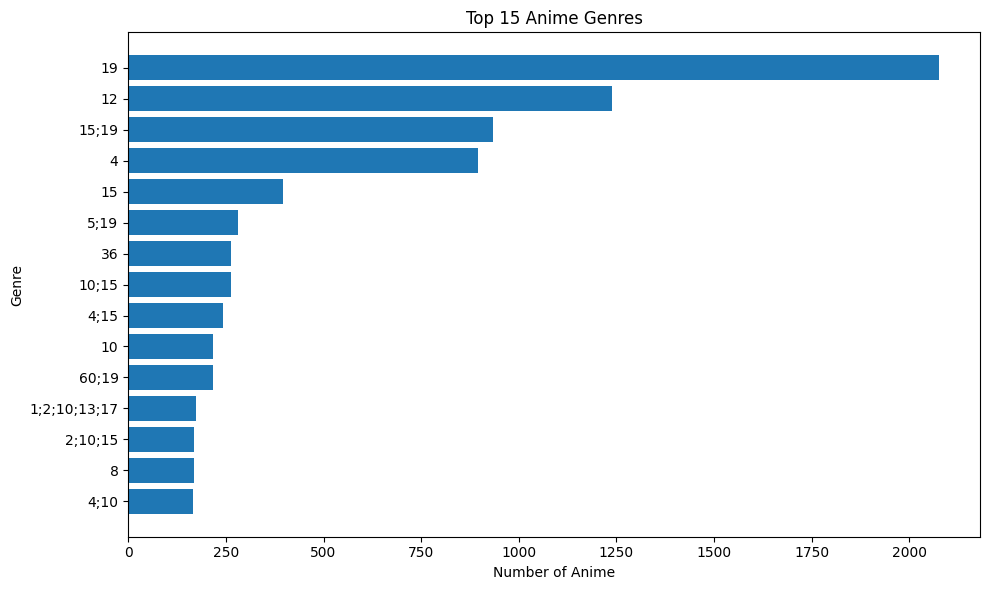

In [12]:
# ==========================================
# 11. GENRE ANALYSIS
# ==========================================

genre_col = None

if "genres" in df.columns:
    genre_col = "genres"
elif "genre" in df.columns:
    genre_col = "genre"

if genre_col:

    genre_series = (
        df[genre_col]
        .dropna()
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
    )

    # Remove empty values
    genre_series = genre_series[
        genre_series != ""
    ]

    genre_counts = (
        genre_series
        .value_counts()
        .head(15)
    )

    print("Top 15 Anime Genres:")
    display(
        genre_counts.rename("Count").to_frame()
    )

    # Convert Index and values to NumPy arrays
    genre_names = genre_counts.index.astype(str).to_numpy()
    genre_values = genre_counts.to_numpy()

    # Reverse for horizontal bar chart
    genre_names = genre_names[::-1]
    genre_values = genre_values[::-1]

    plt.figure(figsize=(10, 6))

    plt.barh(
        genre_names,
        genre_values
    )

    plt.title("Top 15 Anime Genres")
    plt.xlabel("Number of Anime")
    plt.ylabel("Genre")

    plt.tight_layout()
    plt.show()

else:
    print(
        "The dataset does not contain a genre/genres column."
    )

## 12. Rating vs Popularity


In [13]:
# ==========================================
# 12. RATING VS POPULARITY
# ==========================================

if rating_col and "members" in df.columns:

    corr_data = df[[rating_col, "members"]].dropna()

    if len(corr_data) > 1:

        sample = corr_data.sample(
            min(5000, len(corr_data)),
            random_state=RANDOM_STATE
        )

        plt.figure(figsize=(10, 6))
        plt.scatter(
            sample["members"],
            sample[rating_col],
            alpha=0.5
        )

        plt.xscale("log")
        plt.title("Anime Rating vs Community Members")
        plt.xlabel("Members (log scale)")
        plt.ylabel("Rating")
        plt.tight_layout()
        plt.show()

        print(
            "Correlation:",
            round(
                corr_data[rating_col].corr(
                    corr_data["members"]
                ),
                4
            )
        )


## 13. AI Component — Robust K-Means Clustering

This section is deliberately robust. It does not assume that a particular anime CSV schema is present.

It automatically:
- Finds usable numeric columns.
- Removes invalid values.
- Fills missing numeric values.
- Removes constant columns.
- Applies log transformation to count-like features.
- Standardizes the data.
- Tests valid cluster counts.
- Selects the best K using silhouette score.


In [14]:
# ==========================================
# 13A. PREPARE CLUSTERING DATA
# ==========================================

# Prefer meaningful anime features when they exist
preferred_features = [
    "score",
    "rating",
    "episodes",
    "members",
    "favorites",
    "popularity",
    "ranked"
]

available_features = [
    col for col in preferred_features
    if col in df.columns
]

# Remove duplicate aliases such as score/rating
if "score" in available_features and "rating" in available_features:
    available_features.remove("rating")

if len(available_features) < 2:
    # Fall back to all numeric columns
    numeric_candidates = df.select_dtypes(
        include=np.number
    ).columns.tolist()

    available_features = numeric_candidates

if len(available_features) < 2:
    raise ValueError(
        "At least two numeric features are required "
        "for K-Means clustering."
    )

cluster_base = df[available_features].copy()

# Convert to numeric
for col in cluster_base.columns:
    cluster_base[col] = pd.to_numeric(
        cluster_base[col],
        errors="coerce"
    )

# Replace infinity
cluster_base = cluster_base.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values with median
for col in cluster_base.columns:
    median_value = cluster_base[col].median()

    if pd.isna(median_value):
        cluster_base[col] = 0
    else:
        cluster_base[col] = cluster_base[col].fillna(
            median_value
        )

# Remove constant columns
cluster_base = cluster_base.loc[
    :,
    cluster_base.nunique(dropna=True) > 1
]

if cluster_base.shape[1] < 2:
    raise ValueError(
        "After cleaning, fewer than two useful numeric "
        "features remain."
    )

# Log-transform non-negative count features
for col in ["episodes", "members", "favorites"]:
    if col in cluster_base.columns:
        cluster_base[col] = np.log1p(
            cluster_base[col].clip(lower=0)
        )

print("Features used for clustering:")
print(cluster_base.columns.tolist())

print("\nClustering data shape:")
print(cluster_base.shape)

display(cluster_base.head())


Features used for clustering:
['id', 'mean', 'rank', 'num_list_users', 'num_scoring_users', 'num_episodes', 'average_episode_duration']

Clustering data shape:
(25576, 7)


,id,mean,rank,num_list_users,num_scoring_users,num_episodes,average_episode_duration
0,1,8.75,50.0,2087705,1076292,26,1440
1,5,8.38,247.0,417053,234544,1,6911
2,6,8.22,430.0,845602,405534,26,1480
3,7,7.24,3538.0,132042,46658,26,1500
4,8,6.97,4990.0,16792,6979,52,1380


In [15]:
# ==========================================
# 13B. STANDARDIZE FEATURES
# ==========================================

scaler = StandardScaler()

X = scaler.fit_transform(cluster_base)

# Final safety check
if not np.isfinite(X).all():
    raise ValueError(
        "The standardized clustering matrix contains "
        "invalid values."
    )

print("Standardization completed successfully.")
print("Matrix shape:", X.shape)


Standardization completed successfully.
Matrix shape: (25576, 7)


In [16]:
# ==========================================
# 13C. FIND BEST NUMBER OF CLUSTERS
# ==========================================

scores = []

# Avoid requesting more clusters than available rows
max_k = min(6, len(X) - 1)

if max_k < 2:
    raise ValueError(
        "Not enough records for K-Means clustering."
    )

for k in range(2, max_k + 1):

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(X)

    # Silhouette requires at least 2 unique clusters
    if len(np.unique(labels)) >= 2:

        score = silhouette_score(
            X,
            labels,
            sample_size=min(5000, len(X)),
            random_state=RANDOM_STATE
        )

        scores.append({
            "Clusters": k,
            "Silhouette_Score": score
        })

score_df = pd.DataFrame(scores)

if score_df.empty:
    raise ValueError(
        "No valid K-Means clustering result was produced."
    )

display(score_df)

best_k = int(
    score_df.loc[
        score_df["Silhouette_Score"].idxmax(),
        "Clusters"
    ]
)

print("Selected number of clusters:", best_k)


,Clusters,Silhouette_Score
0,2,0.335310
1,3,0.311380
2,4,0.310882
3,5,0.280637
4,6,0.278396


Selected number of clusters: 2


In [17]:
# ==========================================
# 13D. FINAL K-MEANS MODEL
# ==========================================

final_model = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = final_model.fit_predict(X)

cluster_result = cluster_base.copy()
cluster_result["Cluster"] = cluster_labels

print("Final K-Means model completed successfully!")

display(cluster_result.head())


Final K-Means model completed successfully!


,id,mean,rank,num_list_users,num_scoring_users,num_episodes,average_episode_duration,Cluster
0,1,8.75,50.0,2087705,1076292,26,1440,1
1,5,8.38,247.0,417053,234544,1,6911,1
2,6,8.22,430.0,845602,405534,26,1480,1
3,7,7.24,3538.0,132042,46658,26,1500,1
4,8,6.97,4990.0,16792,6979,52,1380,1


In [18]:
# ==========================================
# 13E. CLUSTER SUMMARY
# ==========================================

cluster_summary = (
    cluster_result
    .groupby("Cluster")
    .size()
    .reset_index(name="Number_of_Anime")
)

display(cluster_summary)

print("Cluster summary generated successfully.")


,Cluster,Number_of_Anime
0,0,17979
1,1,7597


Cluster summary generated successfully.


## 14. AI Cluster Visualization


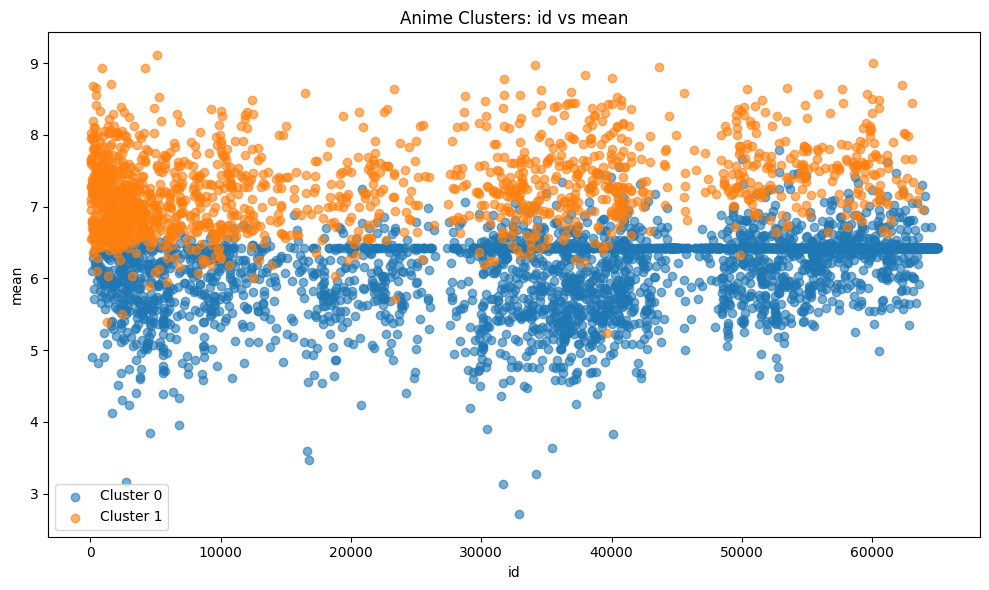

In [19]:
# ==========================================
# 14. CLUSTER VISUALIZATION
# ==========================================

# Use the first two available clustering features
plot_features = list(cluster_base.columns[:2])

plot_df = cluster_result.sample(
    min(5000, len(cluster_result)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 6))

for cluster_id in sorted(plot_df["Cluster"].unique()):

    subset = plot_df[
        plot_df["Cluster"] == cluster_id
    ]

    plt.scatter(
        subset[plot_features[0]],
        subset[plot_features[1]],
        alpha=0.6,
        label=f"Cluster {cluster_id}"
    )

plt.title(
    f"Anime Clusters: {plot_features[0]} vs "
    f"{plot_features[1]}"
)

plt.xlabel(plot_features[0])
plt.ylabel(plot_features[1])
plt.legend()
plt.tight_layout()
plt.show()


## 15. Final Key Findings


In [20]:
# ==========================================
# 15. FINAL PROJECT SUMMARY
# ==========================================

print("=" * 60)
print("ANIME DATASET ANALYSIS — FINAL SUMMARY")
print("=" * 60)

print(f"Total anime records: {len(df)}")

if rating_col:
    valid_scores = df.loc[
        df[rating_col].notna() &
        (df[rating_col] > 0),
        rating_col
    ]

    if len(valid_scores) > 0:
        print(
            f"Average rating: "
            f"{valid_scores.mean():.2f}"
        )

if "members" in df.columns:

    name_col = (
        "name"
        if "name" in df.columns
        else (
            "title"
            if "title" in df.columns
            else df.columns[0]
        )
    )

    print("\nMost popular anime:")

    display(
        df.sort_values(
            "members",
            ascending=False
        )[[name_col, "members"]].head(5)
    )

if genre_col:

    print("\nMost common genres:")

    display(
        genre_counts.head(5)
    )

print(
    f"\nSelected K for AI clustering: {best_k}"
)

display(score_df)

print("\nProject completed successfully!")


ANIME DATASET ANALYSIS — FINAL SUMMARY
Total anime records: 25576

Most common genres:


genres
19       2077
12       1239
15;19     935
4         896
15        396
Name: count, dtype: int64


Selected K for AI clustering: 2


,Clusters,Silhouette_Score
0,2,0.335310
1,3,0.311380
2,4,0.310882
3,5,0.280637
4,6,0.278396



Project completed successfully!


## Dataset Source

This notebook uses a **public CSV URL** and does not require a local `anime.csv` file.

**Public dataset repository:**
https://github.com/meesvandongen/anime-dataset

**Direct public CSV URL used by this notebook:**
https://raw.githubusercontent.com/meesvandongen/anime-dataset/main/data/anime.csv
